In [1]:
# Importações
import sys
import os
import pathlib
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import shap
import torch.nn as nn

# Detecção do root folder
notebook_path = pathlib.Path().absolute()
root_folder = notebook_path.parent

# Adicionar src ao path
SRC_DIR = root_folder
sys.path.append(str(SRC_DIR))

# Importar módulos do projeto
from src.utils.serialization import save_checkpoint
from src.utils.reprodutibility import set_seed
from src.data.dataset import Sample
from src import create_experiment, save_model
from src import (
    ConfigLoader, load_feature_config, load_split_config, load_config,
    HydroDataset, create_dataset_for_training_validation, create_temporal_split_with_gap,
    Seq2SeqHydro, train_model, predict_autoregressive,
    custom_collate_fn, get_device,
    compute_flow_metrics,
    print_metrics_summary,
    plot_predictions_with_context,
    plot_metrics_by_horizon,
    plot_full_series_with_d1_forecast,
    plot_predictions_extremes
)

# Configurações de caminhos
CONFIG_DIR = root_folder / "config"
DATA_DIR = root_folder / "data"
PROCESSED_DIR = DATA_DIR / "processed"

print(f"📁 Root folder: {root_folder}")
print(f"📁 Config: {CONFIG_DIR}")
print(f"📁 Processed data: {PROCESSED_DIR}")


c:\Users\emily\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📁 Root folder: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo
📁 Config: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\config
📁 Processed data: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\data\processed


In [2]:
set_seed(42)

🔒 Seed fixada em: 42


Observação sobre adicionar features: Se adicionar uma feature nova, a matriz de pesos da primeira camada mudará de tamanho (de N para N+1). É impossível ter exatamente os mesmos pesos, pois a arquitetura mudou. Porém, ao fixar a seed, os pesos das features antigas serão inicializados com os mesmos valores de antes, e a nova feature terá uma inicialização aleatória determinística. É a melhor comparação possível.

In [3]:
# Carregar configurações
print("\n⚙️ Carregando configurações...")
data_config = load_config(CONFIG_DIR / "data_config.yaml")
model_config = load_config(CONFIG_DIR / "model_config.yaml")
train_config = load_config(CONFIG_DIR / "training_config.yaml")

# Extrair configurações
stations = data_config["stations"]
flow_window_config = data_config["flow_window_config"]
climate_window_config = data_config["climate_window_config"]
temporal_features = data_config["temporal_features"]
api_k_list = data_config["api_k_list"]
static_keys = data_config["static_keys"]
static_attributes_dict = data_config["static_attributes"]
window_stride = data_config['split_config']['window_stride']
horizon = data_config["horizon"]
experiment_name = data_config["experiment_name"]
train_ratio = data_config['split_config']['train_ratio']
test_ratio = data_config['split_config']['test_ratio']
val_ratio = data_config['split_config']['val_ratio']

print(f"✓ {len(stations)} estações carregadas")
print(f"✓ Configurações de modelo carregadas")
print(f"✓ Configurações de treino carregadas")
print(f"✓ Atributos estáticos de {len(static_attributes_dict)} estações carregados")


⚙️ Carregando configurações...
✓ 3 estações carregadas
✓ Configurações de modelo carregadas
✓ Configurações de treino carregadas
✓ Atributos estáticos de 3 estações carregados


In [4]:
# Criar experimento (faz merge automático dos 3 YAMLs)
exp_path = create_experiment(
    config_paths={
        "data": "config/data_config.yaml",
        "model": "config/model_config.yaml",
        "training": "config/training_config.yaml"
    },
    experiment_name=experiment_name,
    description="Modelo LSTM baseline com 30 dias de histórico sem loss de direção"
)

📌 Branch detectada: Improve_model_performance

CRIANDO NOVO EXPERIMENTO: exp_008_Improve_model_performance_no_loss_direction

✓ Criado: exp_008_Improve_model_performance_no_loss_direction\config
✓ Criado: exp_008_Improve_model_performance_no_loss_direction\model
✓ Criado: exp_008_Improve_model_performance_no_loss_direction\logs
✓ Criado: exp_008_Improve_model_performance_no_loss_direction\predictions_test\raw
✓ Criado: exp_008_Improve_model_performance_no_loss_direction\predictions_test\metrics
✓ Criado: exp_008_Improve_model_performance_no_loss_direction\predictions_test\plots
✓ Criado: exp_008_Improve_model_performance_no_loss_direction\predictions_operational\raw
✓ Criado: exp_008_Improve_model_performance_no_loss_direction\predictions_operational\plots

📋 Copiando arquivos de configuração...
  ✓ data_config.yaml
  ✓ model_config.yaml
  ✓ training_config.yaml

🔀 Criando full_config.yaml (merged)...
  ✓ full_config.yaml

✓ Criado: logs/run_info.txt
✓ Criado: logs/metadata.json
✅ EXPE

In [5]:
#Carregar dados processados
print("\n📊 Carregando dados processados...")
features_file = PROCESSED_DIR / "features_combined.csv"

if not features_file.exists():
    raise FileNotFoundError(f"Arquivo de features não encontrado: {features_file}")

combined_df = pd.read_csv(features_file)
combined_df['date'] = pd.to_datetime(combined_df['date'])
combined_df = combined_df.set_index('date')

print(f"✓ Dados carregados: {len(combined_df)} dias")
print(f"  Período: {combined_df.index.min().date()} a {combined_df.index.max().date()}")
print(f"  Colunas: {len(combined_df.columns)}")


📊 Carregando dados processados...


✓ Dados carregados: 6330 dias
  Período: 1995-01-01 a 2012-04-30
  Colunas: 67


In [6]:
# Criar dataset
print("\n📦 Criando dataset..")
train_ratio = data_config["split_config"]["train_ratio"]
train_indices = np.arange(0, int(len(combined_df) * train_ratio))

ds_full = create_dataset_for_training_validation(
    df=combined_df,
    stations=stations,
    static_attrs=static_attributes_dict,
    train_indices=train_indices,
    flow_window_config=flow_window_config,
    climate_window_config=climate_window_config,
    temporal_features=temporal_features,
    api_k_list=api_k_list,
    static_keys=static_keys,
    horizon = horizon,
    use_last_days_as_forecast=True,  
    window_stride=window_stride,
)

print(f"✓ Dataset criado")
print(f"  Total de samples: {len(ds_full)}")
print(f"  Encoder length: {ds_full.encoder_length}")
print(f"  Decoder length: {ds_full.decoder_length}")
print(f"  Decoder history: {ds_full.decoder_history}")
print(f"  Decoder horizon: {ds_full.decoder_horizon}")


📦 Criando dataset..
✓ Dataset criado
  Total de samples: 6271
  Encoder length: 30
  Decoder length: 45
  Decoder history: 30
  Decoder horizon: 15


In [7]:
train_ds, val_ds, test_ds = create_temporal_split_with_gap(
    dataset=ds_full,
    train_ratio=train_ratio,   # 95% treino
    val_ratio=val_ratio,    # 2.5% validação
    test_ratio=test_ratio,   # 2.5% teste
    gap=128
)

print(f"✓ Split criado")
print(f"  Treino: {len(train_ds)} samples")
print(f"  Validação: {len(val_ds)} samples")
print(f"  Validação: {len(test_ds)} samples")

✓ Split criado
  Treino: 5957 samples
  Validação: 29 samples
  Validação: 157 samples


In [8]:
# Célula 8: Criar DataLoaders
print("\n🔄 Criando DataLoaders...")

train_loader = DataLoader(
    train_ds, 
    batch_size=train_config["batch_size"], 
    shuffle=True, 
    drop_last=True, 
    collate_fn=custom_collate_fn
)

val_loader = DataLoader(
    val_ds, 
    batch_size=train_config["batch_size"],  
    shuffle=False, 
    collate_fn=custom_collate_fn
)

print(f"✓ DataLoaders criados")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")



🔄 Criando DataLoaders...
✓ DataLoaders criados
  Train batches: 93
  Val batches: 1


In [9]:
# Verificar dimensões
print("\n📐 Verificando dimensões...")
sample = ds_full[0]

encoder_input_dim = sample.encoder_dyn.shape[-1]
decoder_dyn_features = sample.decoder_dyn.shape[-1]
temporal_features_dim = sample.temporal_dec.shape[-1]
n_stations = len(stations)
decoder_input_dim = decoder_dyn_features + temporal_features_dim + n_stations
static_dim = sample.static.shape[-1]

print(f"✓ Dimensões calculadas:")
print(f"  Encoder input dim: {encoder_input_dim}")
print(f"  Decoder input dim: {decoder_input_dim}")
print(f"  Static dim: {static_dim}")
print(f"  N stations: {n_stations}")



📐 Verificando dimensões...
✓ Dimensões calculadas:
  Encoder input dim: 66
  Decoder input dim: 58
  Static dim: 12
  N stations: 3


In [10]:
# Criar modelo
print("\n🧠 Criando modelo...")
device = get_device()

# Extrair parâmetros do modelo
arch_config = model_config["architecture"]
gate_config = model_config["gate"]
reg_config = model_config["regularization"]

model = Seq2SeqHydro(
    encoder_input_dim=encoder_input_dim,
    decoder_input_dim=decoder_input_dim,
    n_static=static_dim,
    hidden_dim=arch_config["hidden_dim"],
    num_layers=arch_config["num_layers"],
    dropout=arch_config["dropout"],
    n_stations=n_stations,
    attention=arch_config["attention"],
    residual=arch_config["residual"],
    non_negative=arch_config["non_negative"],
    input_noise_std=reg_config["input_noise_std"],
    y_prev_dropout_p=reg_config["y_prev_dropout_p"],
    gate_y_prev=gate_config["y_prev"],
    tf_step_decay=reg_config["tf_step_decay"],
    y_prev_mask_p=reg_config["y_prev_mask_p"],
    decoder_feat_dropout_p=reg_config["decoder_feat_dropout_p"],
    gate_from_inputs=gate_config["from_inputs"],
    clamp_gate_by_ceiling=gate_config["clamp_by_ceiling"],
    gate_ceiling_min=gate_config["ceiling_min"],
    detach_y_prev_in_gate=gate_config["detach_y_prev"],
    y_prev_mask_step_gamma=reg_config["y_prev_mask_step_gamma"],
    gate_min=gate_config["min"],
    gate_max=gate_config["max"],
)

print(f"✓ Modelo criado")
print(f"  Parâmetros totais: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Device: {device}")


🧠 Criando modelo...
✓ Modelo criado
  Parâmetros totais: 3,181,830
  Device: cpu


In [ ]:
# Célula 11: Treinar modelo
print("\n🚀 Iniciando treino...")
trained_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    decoder_history=ds_full.decoder_history,
    decoder_horizon=ds_full.decoder_horizon,
    max_epochs=train_config["epochs"],
    initial_teacher_forcing=train_config["teacher_forcing"]["initial"],
    teacher_forcing_decay=train_config["teacher_forcing"]["decay"],
    final_teacher_forcing=train_config["teacher_forcing"]["final"],
    free_run_tail=train_config["teacher_forcing"]["free_run_tail"],
    lambda_smooth=train_config["loss_weights"]["smooth"],
    lambda_negative=train_config["loss_weights"]["negative"],
    lambda_continuity=train_config["loss_weights"]["continuity"],
    lambda_slope=train_config["loss_weights"]["slope"],
    horizon_weight_mode=train_config["horizon_weights"]["mode"],
    horizon_weight_gamma=train_config["horizon_weights"]["gamma"],
    early_free_run_patience=train_config["teacher_forcing"]["early_free_run_patience"],
    lambda_gate_bias=train_config["loss_weights"]["gate_bias"],
    gate_decay=train_config["gate_decay"],
    lambda_direction=train_config["loss_weights"]["direction"],
    direction_start=train_config["direction"]["start"],
    dir_weight_gamma=train_config["direction"]["weight_gamma"],
    patience=train_config["early_stopping"]["patience"],
    min_delta=train_config["early_stopping"]["min_delta"],
    learning_rate=train_config["learning_rate"],
    weight_decay=train_config["weight_decay"],
    clip_grad_norm=train_config["clip_grad_norm"],
    device=device,
)

print("✓ Treino concluído!")


🚀 Iniciando treino...


In [26]:
'''from src import save_model

# ==========================================
# OPÇÃO 1: USO COMPLETO (RECOMENDADO)
# ==========================================

# Montar configuração do modelo
model_config = {
    "encoder_input_dim": encoder_input_dim,
    "decoder_input_dim": decoder_input_dim,
    "n_static": static_dim,
    "hidden_dim": arch_config["hidden_dim"],
    "num_layers": arch_config["num_layers"],
    "dropout": arch_config["dropout"],
    "n_stations": n_stations,
    "attention": arch_config["attention"],
    "residual": arch_config["residual"],
    "non_negative": arch_config["non_negative"],
    "input_noise_std": reg_config["input_noise_std"],
    "y_prev_dropout_p": reg_config["y_prev_dropout_p"],
    "gate_y_prev": gate_config["y_prev"],
    "tf_step_decay": reg_config["tf_step_decay"],
    "y_prev_mask_p": reg_config["y_prev_mask_p"],
    "decoder_feat_dropout_p": reg_config["decoder_feat_dropout_p"],
    "gate_from_inputs": gate_config["from_inputs"],
    "clamp_gate_by_ceiling": gate_config["clamp_by_ceiling"],
    "gate_ceiling_min": gate_config["ceiling_min"],
    "detach_y_prev_in_gate": gate_config["detach_y_prev"],
    "y_prev_mask_step_gamma": reg_config["y_prev_mask_step_gamma"],
    "gate_min": gate_config["min"],
    "gate_max": gate_config["max"],
}

# Informações de treinamento
training_info = {
    "final_epoch": epoch,
    "best_val_loss": best_val,
    "final_train_loss": avg_train,
    "device": str(device)
}

# Salvar (TUDO É EXTRAÍDO AUTOMATICAMENTE!)
save_model(
    model=trained_model,
    experiment_name=experiment_name,
    dataset=ds_full,  # ✅ Dataset completo - extrai TUDO automaticamente
    model_config=model_config,  # ✅ Config completa da arquitetura
    #training_info=training_info  # ✅ Info do treinamento
)'''

'from src import save_model\n\n# ==========================================\n# OPÇÃO 1: USO COMPLETO (RECOMENDADO)\n# ==========================================\n\n# Montar configuração do modelo\nmodel_config = {\n    "encoder_input_dim": encoder_input_dim,\n    "decoder_input_dim": decoder_input_dim,\n    "n_static": static_dim,\n    "hidden_dim": arch_config["hidden_dim"],\n    "num_layers": arch_config["num_layers"],\n    "dropout": arch_config["dropout"],\n    "n_stations": n_stations,\n    "attention": arch_config["attention"],\n    "residual": arch_config["residual"],\n    "non_negative": arch_config["non_negative"],\n    "input_noise_std": reg_config["input_noise_std"],\n    "y_prev_dropout_p": reg_config["y_prev_dropout_p"],\n    "gate_y_prev": gate_config["y_prev"],\n    "tf_step_decay": reg_config["tf_step_decay"],\n    "y_prev_mask_p": reg_config["y_prev_mask_p"],\n    "decoder_feat_dropout_p": reg_config["decoder_feat_dropout_p"],\n    "gate_from_inputs": gate_config["from

In [ ]:
# 1. Coletar metadados do dataset
inference_meta = {
    "flow_scalers": ds_full.flow_scalers,
    "climate_scalers": ds_full.climate_scalers,
    "static_scalers": ds_full.static_scalers,
    "stations": ds_full.stations,
    "forecast_cols": ds_full.forecast_cols,
    "flow_window_config": ds_full.flow_window_config,
    "climate_window_config": ds_full.climate_window_config,
    "temporal_features": ds_full.temporal_features,
    "static_keys": ds_full.static_keys,
    "decoder_history": ds_full.decoder_history,
    "decoder_horizon": ds_full.decoder_horizon,
}

# 2. Configuração da Arquitetura (Use as mesmas variáveis da criação do modelo)
# Se você usou um dicionário 'model_params', melhor ainda. Se não, monte agora:
model_config = {
    "encoder_input_dim": encoder_input_dim,
    "decoder_input_dim": decoder_input_dim,
    "n_static": static_dim,
    "hidden_dim":arch_config["hidden_dim"],
    "num_layers":arch_config["num_layers"],
    "dropout":arch_config["dropout"],
    "n_stations":n_stations,
    "attention":arch_config["attention"],
    "residual":arch_config["residual"],
    "non_negative":arch_config["non_negative"],
    "input_noise_std":reg_config["input_noise_std"],
    "y_prev_dropout_p":reg_config["y_prev_dropout_p"],
    "gate_y_prev":gate_config["y_prev"],
    "tf_step_decay":reg_config["tf_step_decay"],
    "y_prev_mask_p":reg_config["y_prev_mask_p"],
    "decoder_feat_dropout_p":reg_config["decoder_feat_dropout_p"],
    "gate_from_inputs":gate_config["from_inputs"],
    "clamp_gate_by_ceiling":gate_config["clamp_by_ceiling"],
    "gate_ceiling_min":gate_config["ceiling_min"],
    "detach_y_prev_in_gate":gate_config["detach_y_prev"],
    "y_prev_mask_step_gamma":reg_config["y_prev_mask_step_gamma"],
    "gate_min":gate_config["min"],
    "gate_max":gate_config["max"],
}

# 3. Salvar
save_checkpoint(
    model=trained_model,
    inference_meta=inference_meta,
    model_config=model_config,
    path="C:/Users/emily/Documents/GitHub/Mini-curso-GitHub-Leo/models/model_unified_columns.pth")

✅ Checkpoint salvo com sucesso em: C:/Users/emily/Documents/GitHub/Mini-curso-GitHub-Leo/models/modelo_correction_mask_dataset.pth


### Shap analysis

In [32]:
# ── CÉLULA SHAP 2: Wrapper do modelo para o SHAP ────────────────────────────
#
# Problema: o SHAP precisa de uma função  tensor → tensor
# mas o forward() do Seq2SeqHydro recebe um objeto Sample.
#
# Solução: wrapper que recebe só encoder_dyn e reconstrói
# o Sample internamente, fixando os demais inputs com a
# média do background (representativa, não arbitrária).

class EncoderSHAPWrapper(nn.Module):
    def __init__(self, model, fixed_sample, decoder_history, decoder_horizon):
        super().__init__()
        self.model = model
        self.decoder_history = decoder_history
        self.decoder_horizon = decoder_horizon

        # Usa parâmetros frozen em vez de buffers — garante grad_fn no grafo
        def to_param(t):
            return nn.Parameter(t.mean(0, keepdim=True).float(), requires_grad=False)

        self.dec_dyn        = to_param(fixed_sample.decoder_dyn)
        self.static_        = to_param(fixed_sample.static)
        self.temporal_enc_  = to_param(fixed_sample.temporal_enc)
        self.temporal_dec_  = to_param(fixed_sample.temporal_dec)
        self.target_        = to_param(fixed_sample.target)
        self.mask_enc_      = to_param(fixed_sample.mask_enc)
        self.mask_dec_      = to_param(fixed_sample.mask_dec)
        self.baseline_last_ = to_param(fixed_sample.baseline_last)

    def forward(self, encoder_dyn):
        B = encoder_dyn.size(0)

        sample = Sample(
            encoder_dyn  = encoder_dyn,  # ← único tensor com gradiente ativo
            decoder_dyn  = self.dec_dyn.expand(B, -1, -1),
            static       = self.static_.expand(B, -1),
            temporal_enc = self.temporal_enc_.expand(B, -1, -1),
            temporal_dec = self.temporal_dec_.expand(B, -1, -1),
            target       = self.target_.expand(B, -1, -1),
            mask_enc     = self.mask_enc_.expand(B, -1, -1),
            mask_dec     = self.mask_dec_.expand(B, -1, -1),
            baseline_last= self.baseline_last_.expand(B, -1),
            forecast_date= None,
            date_index   = None,
        )

        preds, _, _ = self.model(sample, 0.0, self.decoder_history, self.decoder_horizon)
        return preds.mean(dim=(1, 2), keepdim=False).unsqueeze(-1)  # (B, 1)

In [33]:
# ── CÉLULA SHAP 3: Coletar dados do val_loader ──────────────────────────────

def collect_batches(loader, device='cpu'):
    """Concatena todos os batches do loader em um Sample único."""
    keys = ['encoder_dyn', 'decoder_dyn', 'static',
            'temporal_enc', 'temporal_dec', 'target',
            'mask_enc', 'mask_dec', 'baseline_last']
    parts = {k: [] for k in keys}

    for batch in loader:
        for k in keys:
            parts[k].append(getattr(batch, k))

    return Sample(
        **{k: torch.cat(v, dim=0).to(device) for k, v in parts.items()},
        forecast_date=None,
        date_index=None,
    )

# SHAP funciona melhor em CPU — mantém mesmo que o treino tenha sido em GPU
shap_device = 'cpu'
trained_model.eval().to(shap_device)

print('Coletando dados de validação...')
val_sample = collect_batches(val_loader, device=shap_device)

print(f'✓ Total de amostras : {val_sample.encoder_dyn.shape[0]}')
print(f'  encoder_dyn shape : {val_sample.encoder_dyn.shape}')  # (N, enc_len, n_features)
print(f'  decoder_dyn shape : {val_sample.decoder_dyn.shape}')

Coletando dados de validação...
✓ Total de amostras : 297
  encoder_dyn shape : torch.Size([297, 380, 21])
  decoder_dyn shape : torch.Size([297, 153, 48])


In [34]:
# ── CÉLULA SHAP 4: Gerar nomes das features dinamicamente ───────────────────
#
# Espelha EXATAMENTE a ordem do _build_flow_block + _add_encoder_features
# do dataset.py, usando o mesmo _get_cols_by_prefix dinâmico.
# Assim nunca há descompasso entre nomes e tensor, independente das configs.

def get_encoder_feature_names(dataset, stations, flow_window_config):
    """Reconstrói os nomes das features do encoder_dyn na mesma ordem do dataset."""
    names = []

    # ── 1. Flow block (encoder) ──────────────────────────────────────────────
    # Mesma ordem de _build_flow_block com stage='encoder'
    for station in stations:
        for spec in flow_window_config[station]['encoder']:
            source = spec['source']
            names.append(f'Q_{source}→{station}')

    # ── 2. Climate block (encoder) ───────────────────────────────────────────
    # Mesma ordem de _add_encoder_features, usando _get_cols_by_prefix
    for station in stations:

        # 2a. Clima básico
        for col in [f'precipitation_chirps_{station}',
                    f'potential_evapotransp_gleam_{station}']:
            if col in dataset.df.columns:
                names.append(col)

        # 2b. Médias móveis de precipitação (dinâmico — mesma ordem alfabética do dataset)
        for col in dataset._get_cols_by_prefix('precipitation_chirps_ma', station):
            names.append(col)

        # 2c. Acumulados de precipitação (dinâmico)
        for col in dataset._get_cols_by_prefix('precipitation_chirps_cum', station):
            names.append(col)

        # 2d. APIs observadas (dinâmico)
        for col in dataset._get_cols_by_prefix('api_chirps_k', station):
            names.append(col)

        # 2e. Derivadas e regime
        for col in [f'dQ_dt_{station}', f'dP_dt_{station}', f'regime_state_{station}']:
            if col in dataset.df.columns:
                names.append(col)

        # 2f. Log anomaly e suas médias móveis (dinâmico)
        if f'log_anomaly_{station}' in dataset.df.columns:
            names.append(f'log_anomaly_{station}')
        for col in dataset._get_cols_by_prefix('log_anomaly_ma', station):
            names.append(col)

    return names


encoder_feature_names = get_encoder_feature_names(dataset, stations, flow_window_config)

n_names  = len(encoder_feature_names)
n_tensor = val_sample.encoder_dyn.shape[-1]

print(f'Features geradas : {n_names}')
print(f'Features no tensor: {n_tensor}')

if n_names != n_tensor:
    print('\n❌ DIVERGÊNCIA! Lista de nomes gerada:')
    for i, n in enumerate(encoder_feature_names):
        print(f'  [{i:02d}] {n}')
    raise ValueError(
        f'Número de nomes ({n_names}) ≠ features no tensor ({n_tensor}). '
        f'Ajuste get_encoder_feature_names().'
    )
else:
    print('\n✓ Nomes OK! Features na ordem correta:')
    for i, n in enumerate(encoder_feature_names):
        print(f'  [{i:02d}] {n}')

Features geradas : 21
Features no tensor: 21

✓ Nomes OK! Features na ordem correta:
  [00] Q_10100000→10100000
  [01] Q_10100000→13150000
  [02] Q_13150000→13150000
  [03] Q_10100000→14100000
  [04] Q_13150000→14100000
  [05] Q_14100000→14100000
  [06] dQ_dt_10100000
  [07] regime_state_10100000
  [08] log_anomaly_10100000
  [09] log_anomaly_ma3_10100000
  [10] log_anomaly_ma7_10100000
  [11] dQ_dt_13150000
  [12] regime_state_13150000
  [13] log_anomaly_13150000
  [14] log_anomaly_ma3_13150000
  [15] log_anomaly_ma7_13150000
  [16] dQ_dt_14100000
  [17] regime_state_14100000
  [18] log_anomaly_14100000
  [19] log_anomaly_ma3_14100000
  [20] log_anomaly_ma7_14100000


In [35]:
# ── CÉLULA SHAP 5: Calcular SHAP values ─────────────────────────────────────
#
# Background : ~100 amostras (referência do SHAP — "baseline" estatístico)
# Test       : próximas amostras para analisar
#
# GradientExplainer é o mais adequado para Seq2Seq com atenção e gates.
# Mais rápido e estável que KernelExplainer para redes neurais PyTorch.

# ── CÉLULA SHAP 5: Calcular SHAP values ─────────────────────────────────────

N            = val_sample.encoder_dyn.shape[0]
n_background = min(100, N // 2)
n_test       = min(100, N - n_background)

# ✅ requires_grad_(True) — abre o caminho para o GradientExplainer
background_enc = val_sample.encoder_dyn[:n_background].float().requires_grad_(True)
test_enc       = val_sample.encoder_dyn[n_background : n_background + n_test].float().requires_grad_(True)

# Monta wrapper
wrapper = EncoderSHAPWrapper(
    model          = trained_model,
    fixed_sample   = val_sample,
    decoder_history= dataset.decoder_history,
    decoder_horizon= dataset.decoder_horizon,
).to(shap_device)

# ✅ .train() ativa o fluxo de gradientes nas camadas LSTM/Attention
# ✅ zeramos input_noise_std para não distorcer os SHAP values com ruído aleatório
wrapper.model.train()
wrapper.model.input_noise_std = 0.0

explainer = shap.GradientExplainer(wrapper, background_enc)

print(f'Calculando SHAP values para {n_test} amostras...')
print('(pode levar alguns minutos em CPU)')
shap_values = explainer.shap_values(test_enc)
shap_array  = np.array(shap_values)

# ✅ Restaura o modelo para avaliação normal após o SHAP
wrapper.model.eval()
wrapper.model.input_noise_std = 0.0  # seu valor original

print(f'\n✓ SHAP values calculados!')
print(f'  Shape: {shap_array.shape}')  # esperado: (n_test, enc_len, n_features, 1)

Calculando SHAP values para 100 amostras...
(pode levar alguns minutos em CPU)

✓ SHAP values calculados!
  Shape: (100, 380, 21, 1)


shap_array shape final: (100, 380, 21)


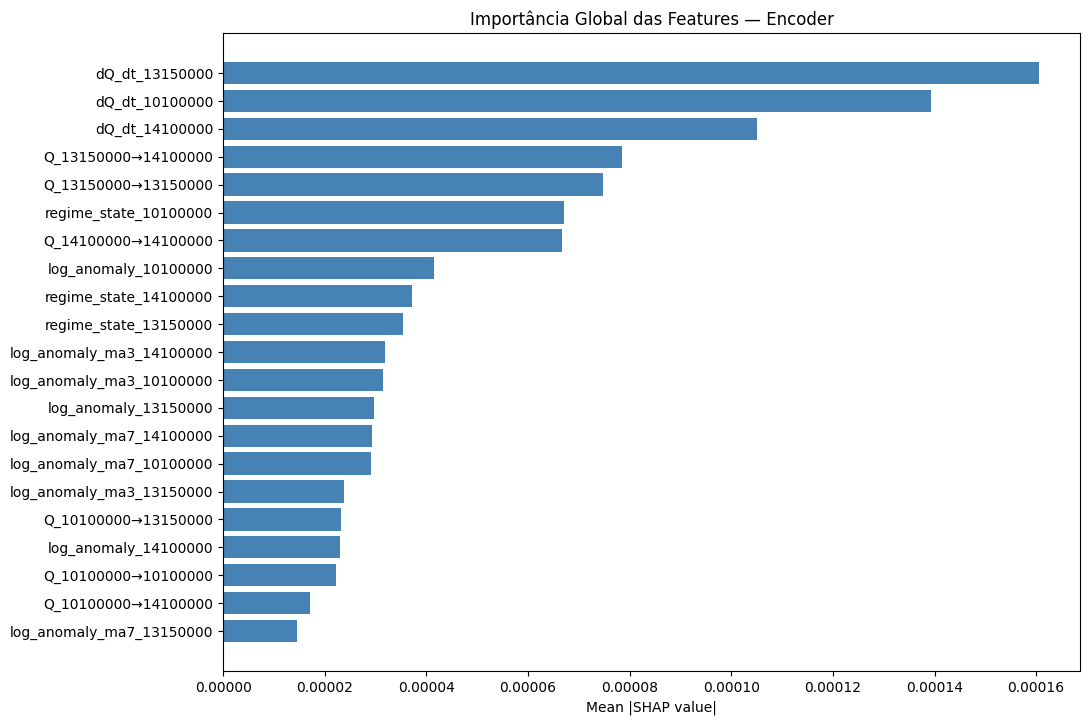


Ranking de importância:
   1. dQ_dt_13150000                                0.00016  ██████████████████████████████
   2. dQ_dt_10100000                                0.00014  ██████████████████████████
   3. dQ_dt_14100000                                0.00011  ███████████████████
   4. Q_13150000→14100000                           0.00008  ██████████████
   5. Q_13150000→13150000                           0.00007  █████████████
   6. regime_state_10100000                         0.00007  ████████████
   7. Q_14100000→14100000                           0.00007  ████████████
   8. log_anomaly_10100000                          0.00004  ███████
   9. regime_state_14100000                         0.00004  ██████
  10. regime_state_13150000                         0.00004  ██████
  11. log_anomaly_ma3_14100000                      0.00003  █████
  12. log_anomaly_ma3_10100000                      0.00003  █████
  13. log_anomaly_13150000                          0.00003  █████
  14. log

In [37]:
# ── CÉLULA SHAP 6: Visualização — Importância Global ────────────────────────

# Remove dimensão extra do unsqueeze(-1) se existir
shap_array_clean = np.array(shap_values)
if shap_array_clean.ndim == 4:
    shap_array_clean = shap_array_clean.squeeze(-1)  # (n_test, enc_len, n_features)

print(f"shap_array shape final: {shap_array_clean.shape}")

# Agrega |SHAP| sobre batch e timesteps → importância média por feature
shap_global = np.abs(shap_array_clean).mean(axis=(0, 1))   # (n_features,)
sorted_idx  = np.argsort(shap_global)[::-1].tolist()        # ✅ .tolist() evita o TypeError

# ── Gráfico de barras horizontal ──
plt.figure(figsize=(11, max(6, len(encoder_feature_names) * 0.35)))
plt.barh(
    [encoder_feature_names[i] for i in sorted_idx[::-1]],
    [shap_global[i] for i in sorted_idx[::-1]],
    color='steelblue',
)
plt.xlabel('Mean |SHAP value|')
plt.title('Importância Global das Features — Encoder')
plt.tight_layout()
plt.show()

# ── Ranking no console ──
print('\nRanking de importância:')
max_val = shap_global[sorted_idx[0]]
for rank, i in enumerate(sorted_idx, 1):
    bar = '█' * int(shap_global[i] / max_val * 30)
    print(f'  {rank:2d}. {encoder_feature_names[i]:<45s} {shap_global[i]:.5f}  {bar}')

C:\Users\emily\AppData\Local\Temp\ipykernel_406972\2206717903.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


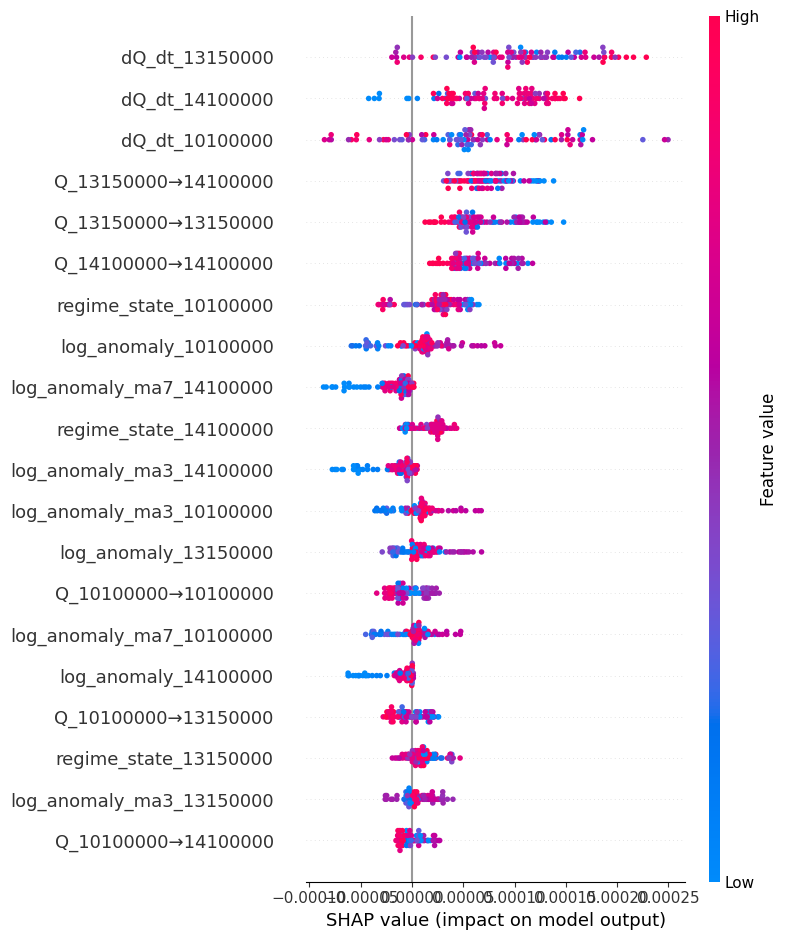

In [38]:
# ── CÉLULA SHAP 7: Summary plot ──────────────────────────────────────────────

shap_flat = shap_array_clean.mean(axis=1)        # (n_test, n_features)
X_flat    = test_enc.detach().numpy().mean(axis=1)  # (n_test, n_features)

shap.summary_plot(
    shap_flat,
    X_flat,
    feature_names=encoder_feature_names,
    max_display=min(20, len(encoder_feature_names)),
    show=True,
)